In [16]:
library(tidyverse)
library(data.table)
suppressMessages(source("code/functions.R"))


Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose




In [3]:
df <- read_csv("output/umi_depths.csv", col_types = "cccccdd")

In [4]:
# "clean" the dataframe from outliers on a given column
clean_outliers <- function(df, column) {
  column <- enquo(column)

  quantiles <- df %>%
    group_by(dataset, subject, chain) %>%
    summarise(Q1 = quantile(!!column, 1 / 4), Q3 = quantile(!!column, 3 / 4), .groups = "keep")

  dfm <- df %>%
    left_join(quantiles, by = c("dataset", "subject", "chain")) %>%
    filter(Q1 <= !!column & !!column <= Q3)

  return(dfm)
}

In [5]:
head(df)

dataset,subject,chain,cell,umi,mean_depth,mean_depth_vdj
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
FL,K1B_S10000,LC,AAACCTGGTCCAGTAT,AACAGTTCGG,21.47007,13.628242
FL,K1B_S10000,LC,AAACCTGGTCCAGTAT,AGTGCAGATT,15.08175,8.481268
FL,K1B_S10000,LC,AAACCTGGTCCAGTAT,ATTTCTTCAT,15.02482,8.913545
FL,K1B_S10000,LC,AAACCTGGTCCAGTAT,CAAGATTCTC,16.97664,12.100865
FL,K1B_S10000,LC,AAACCTGGTCCAGTAT,CACTCGCGCG,16.12555,9.172911
FL,K1B_S10000,LC,AAACCTGGTCCAGTAT,CCGGGCCTGC,13.88759,10.628242


In [6]:
df %>% pull(dataset) %>% table()

.
    FL    MBL 
345920 170698 

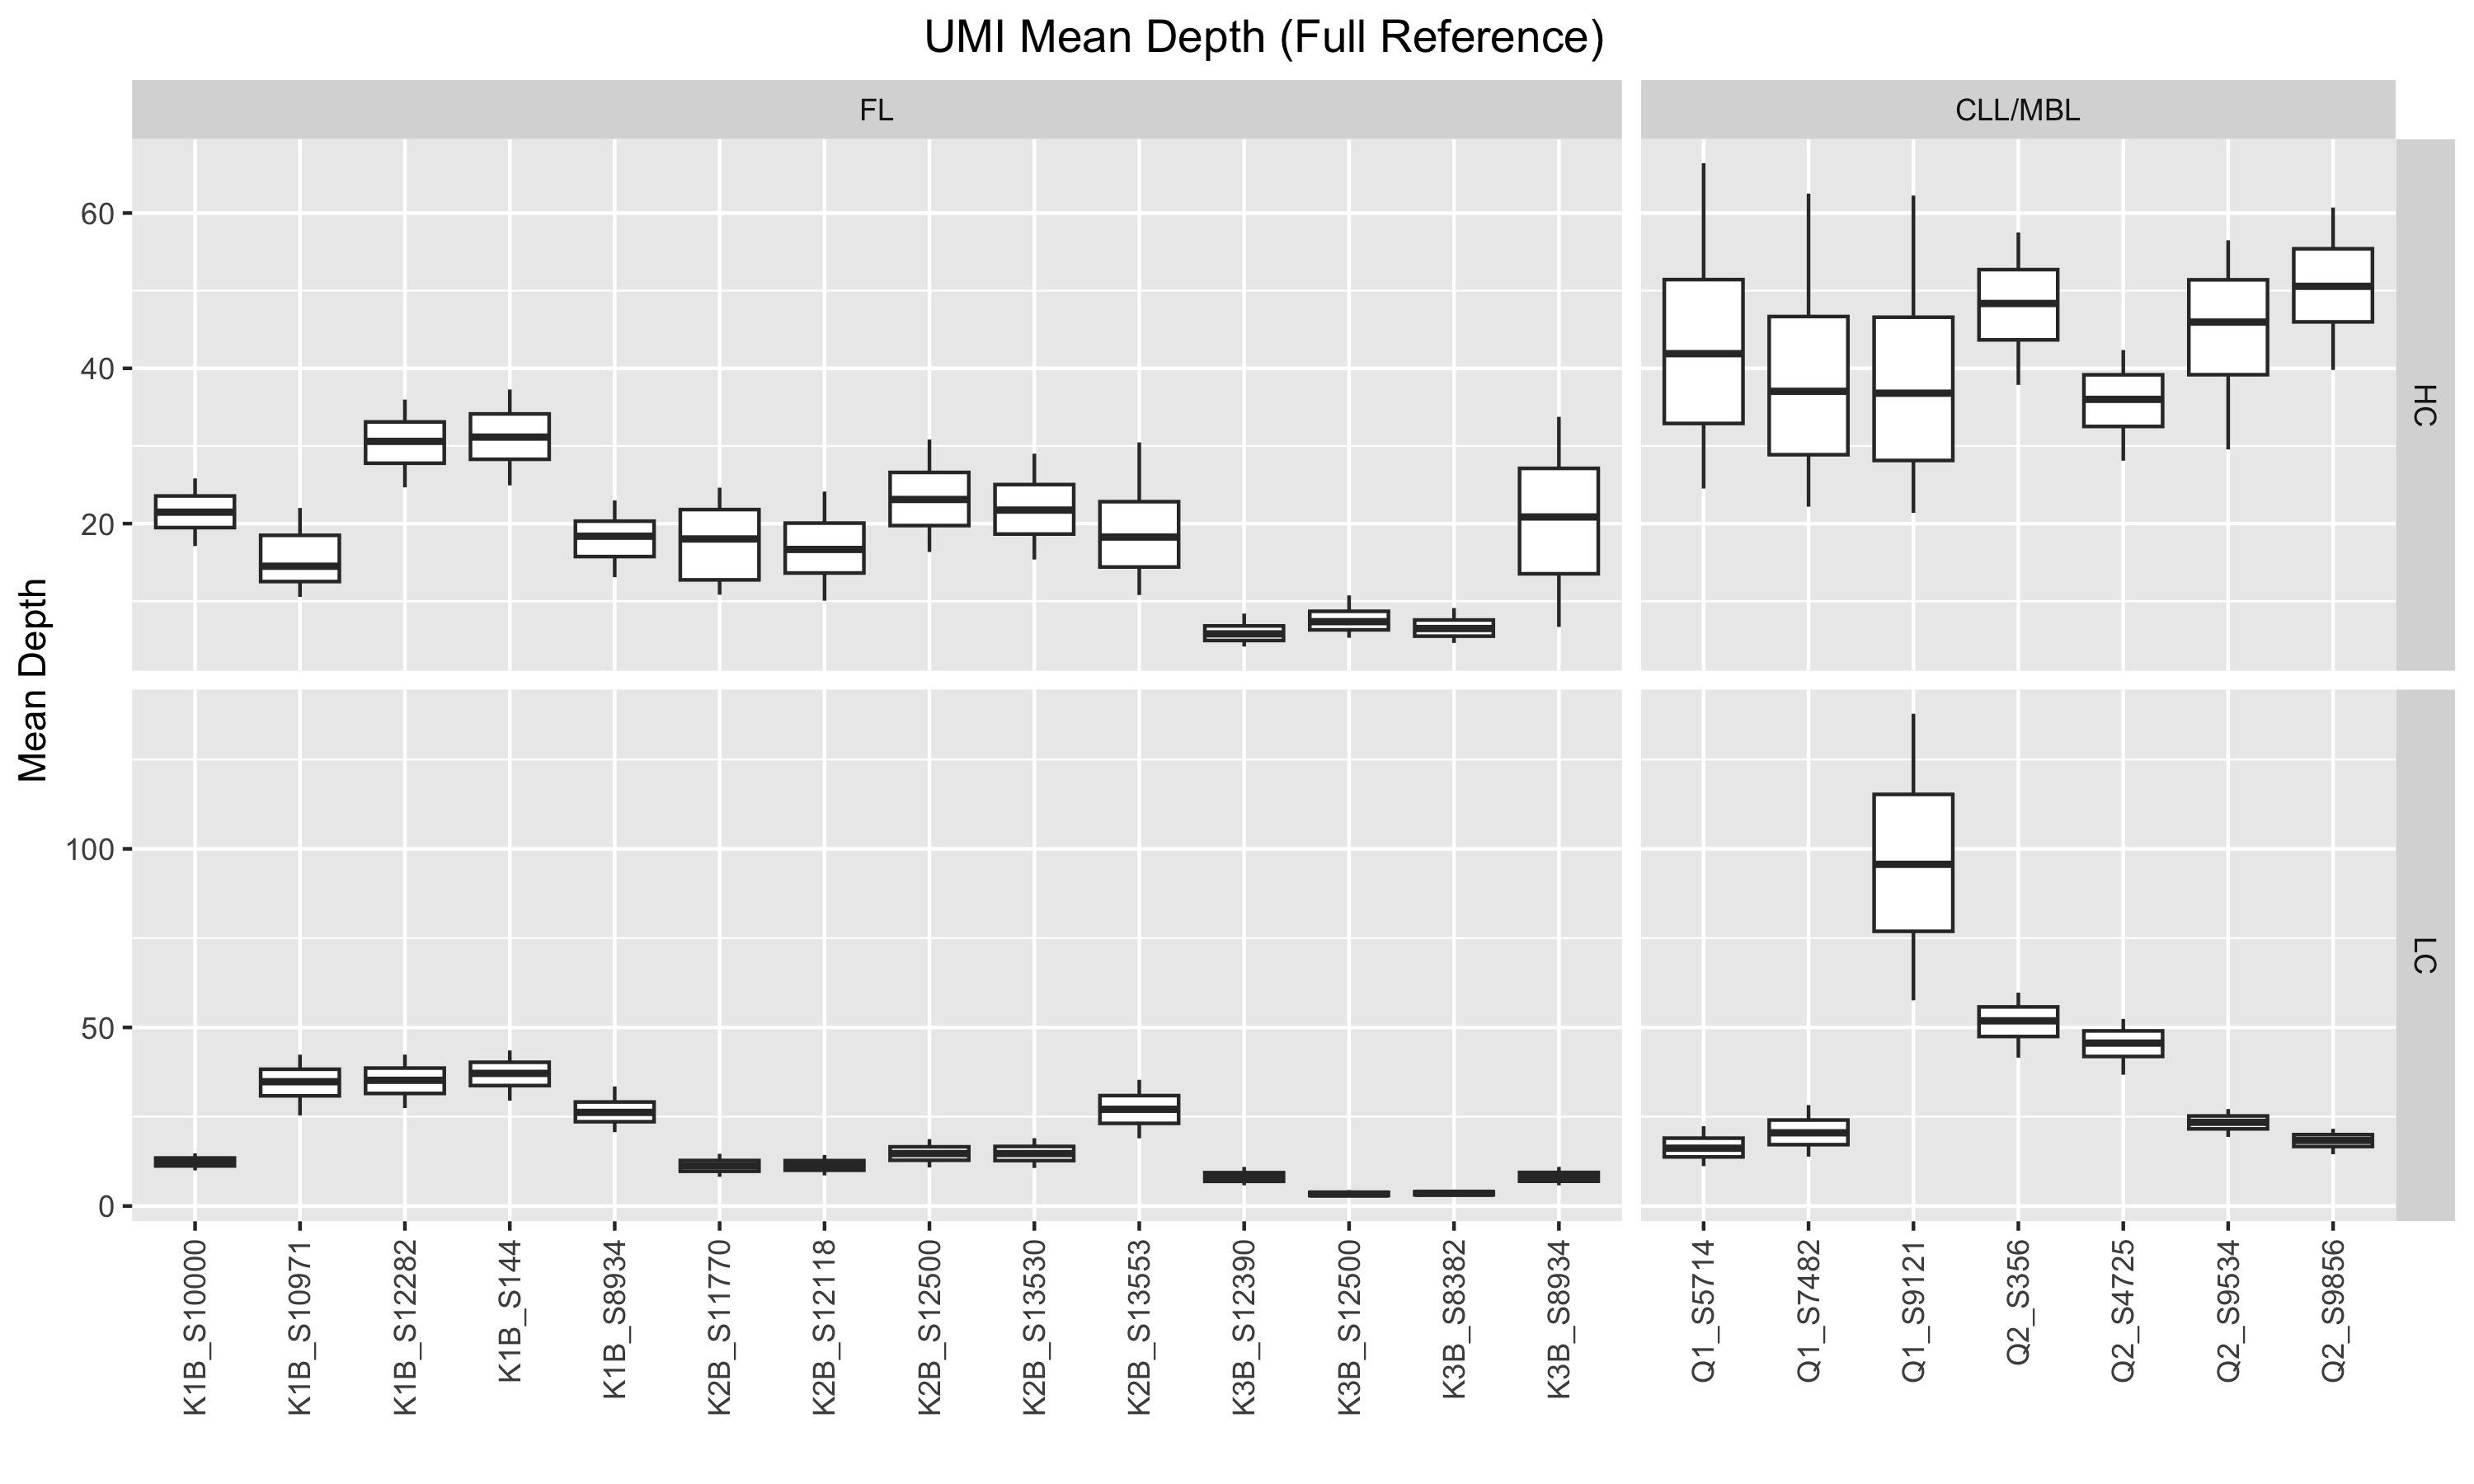

In [7]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 300)

# New facet label names for supp variable
supp.labs <- c("FL", "CLL/MBL")
names(supp.labs) <- c("FL", "MBL")

ggplot(clean_outliers(df, mean_depth), aes(x = subject, y = mean_depth)) +
  geom_boxplot() +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    plot.title = element_text(hjust = 0.5)
  ) +
  facet_grid(chain ~ dataset, scales = "free", space = "free_x",labeller = labeller( dataset = supp.labs)) +
  labs(x = "", y = "Mean Depth") +
  ggtitle("UMI Mean Depth (Full Reference)")

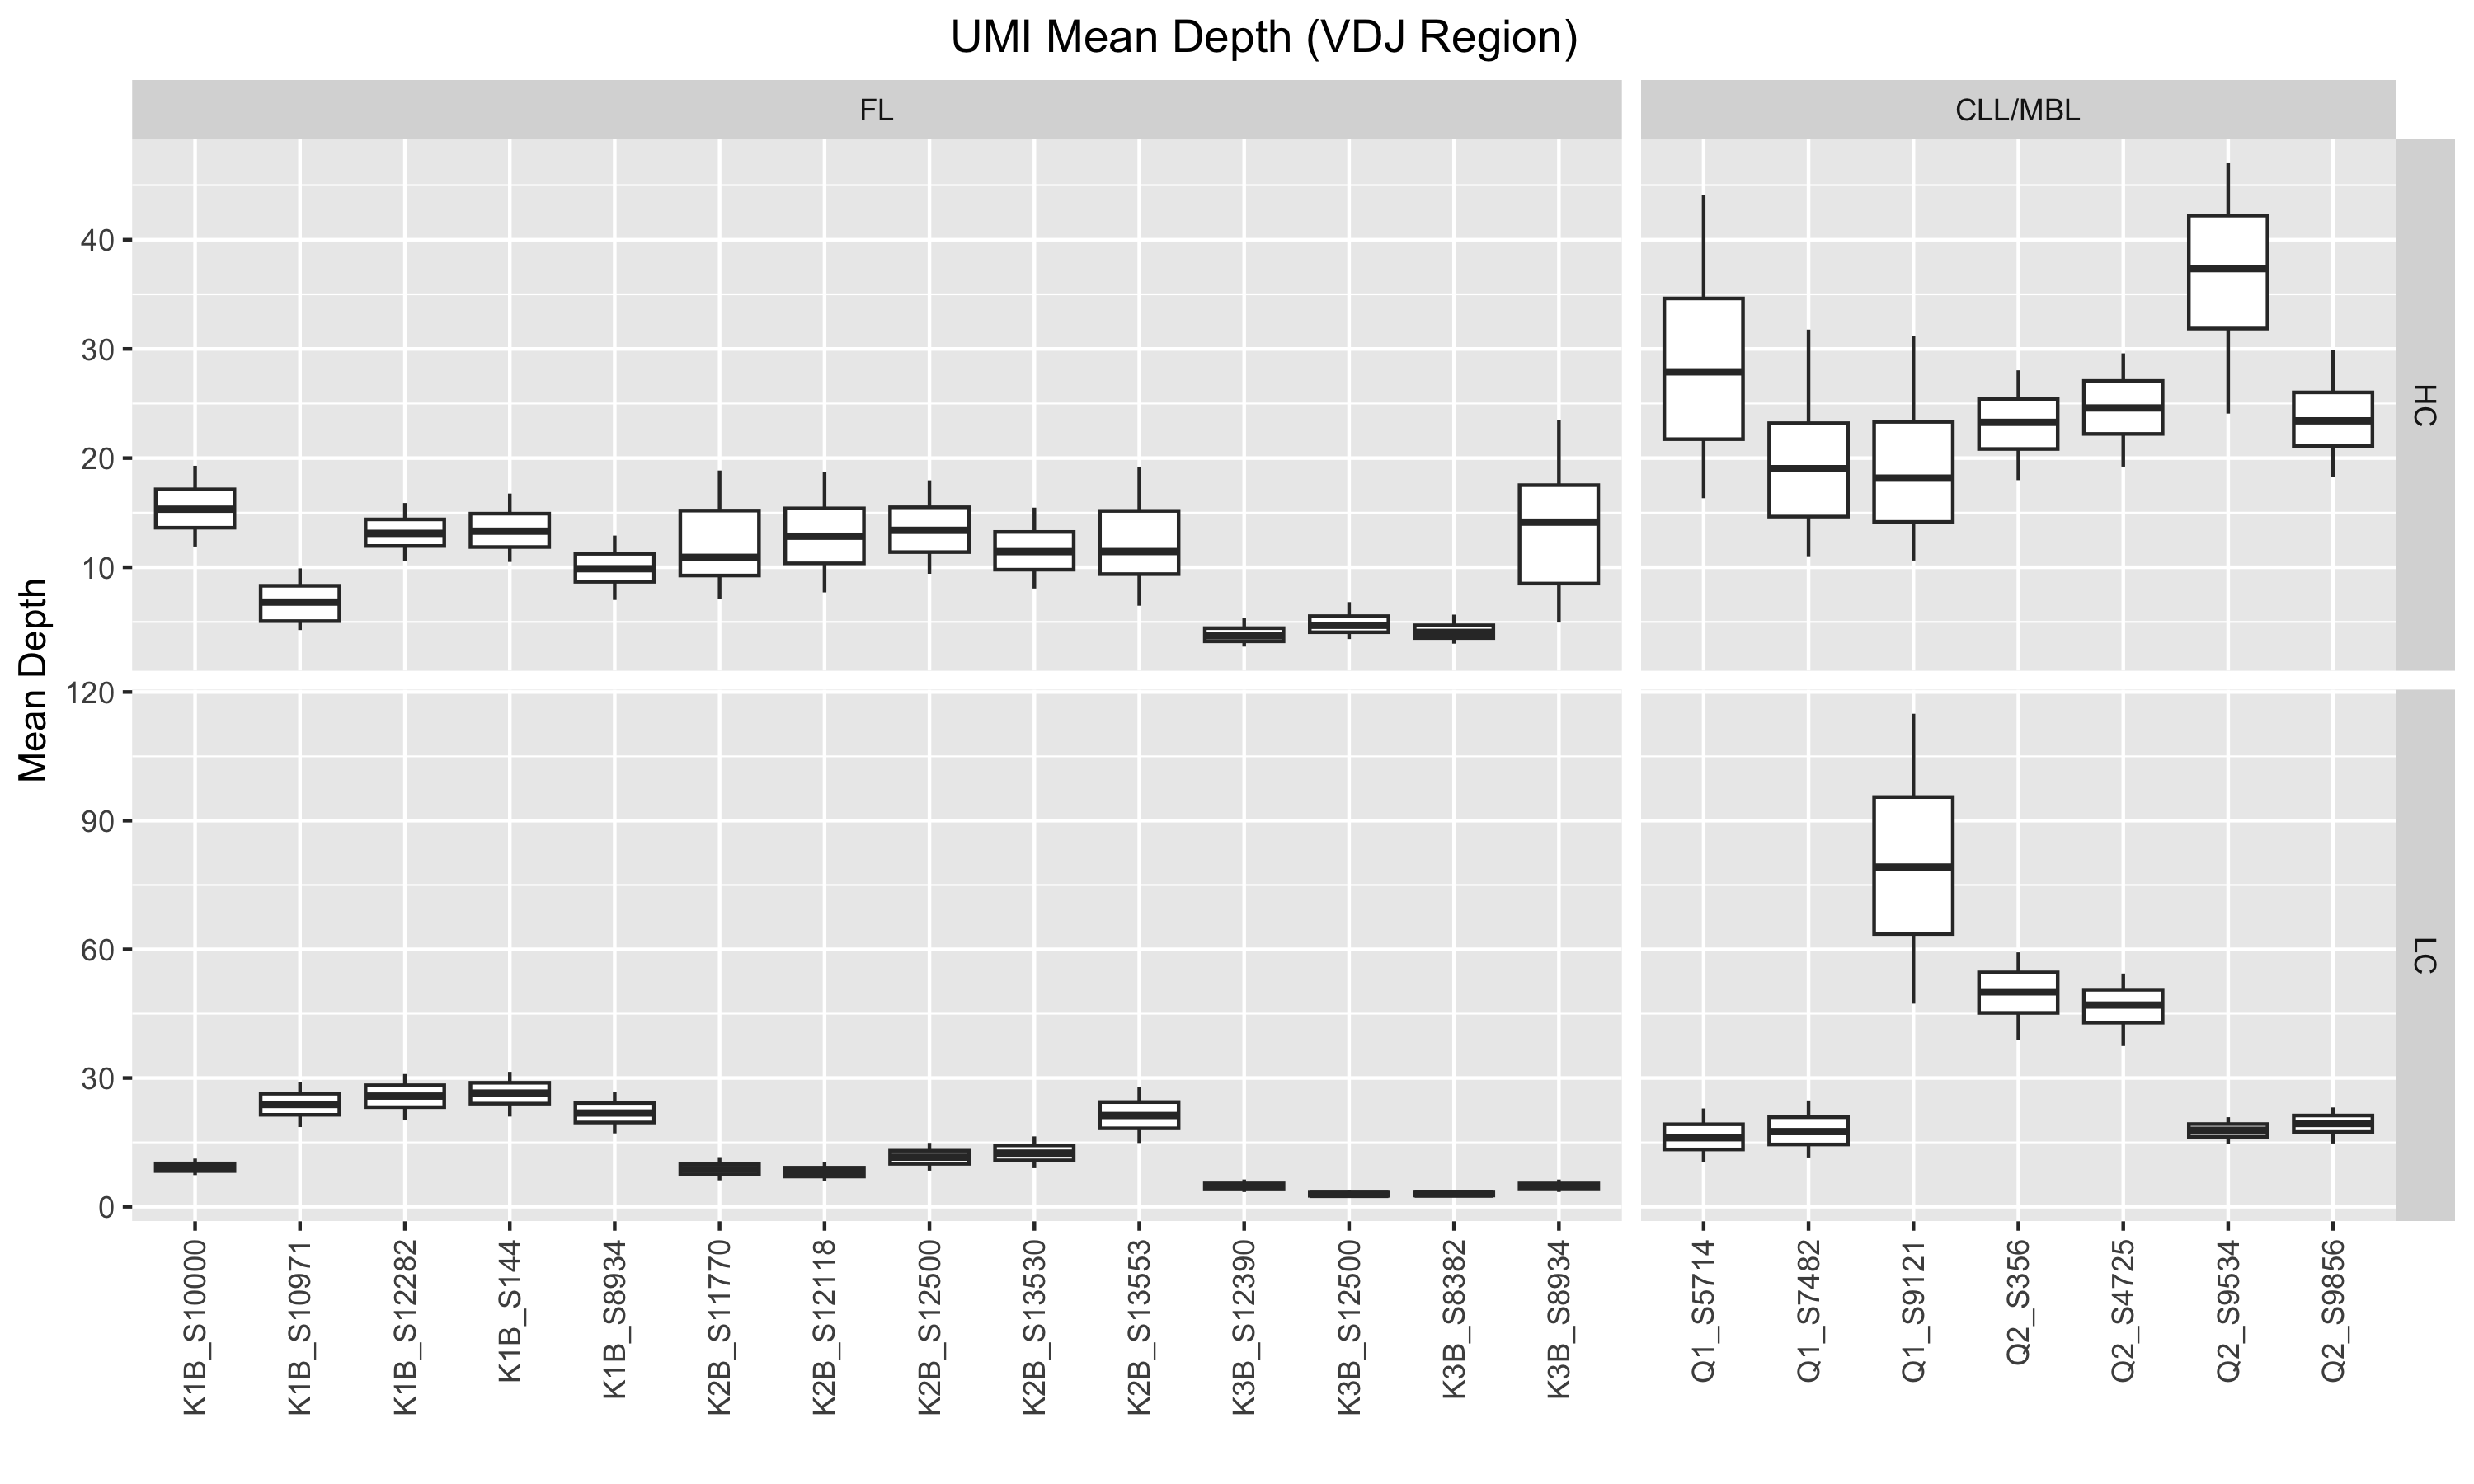

In [8]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 300)

# New facet label names for supp variable
supp.labs <- c("FL", "CLL/MBL")
names(supp.labs) <- c("FL", "MBL")

dd <- ggplot(clean_outliers(df, mean_depth_vdj), aes(x = subject, y = mean_depth_vdj)) +
  geom_boxplot() +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    plot.title = element_text(hjust = 0.5)
  ) +
  facet_grid(chain ~ dataset, scales = "free", space = "free_x",labeller = labeller( dataset = supp.labs)) +
  labs(x = "", y = "Mean Depth") +
  ggtitle("UMI Mean Depth (VDJ Region)")

dd

fig_save(dd, filename = ("figs/umi_mean_depth_VDJ_region"), formats = c("pdf", "png"), width = 25, height =12, units = "cm", dpi = 320)

In [19]:
mbl_samples <- c("Q1_9121", "Q2_S9534")

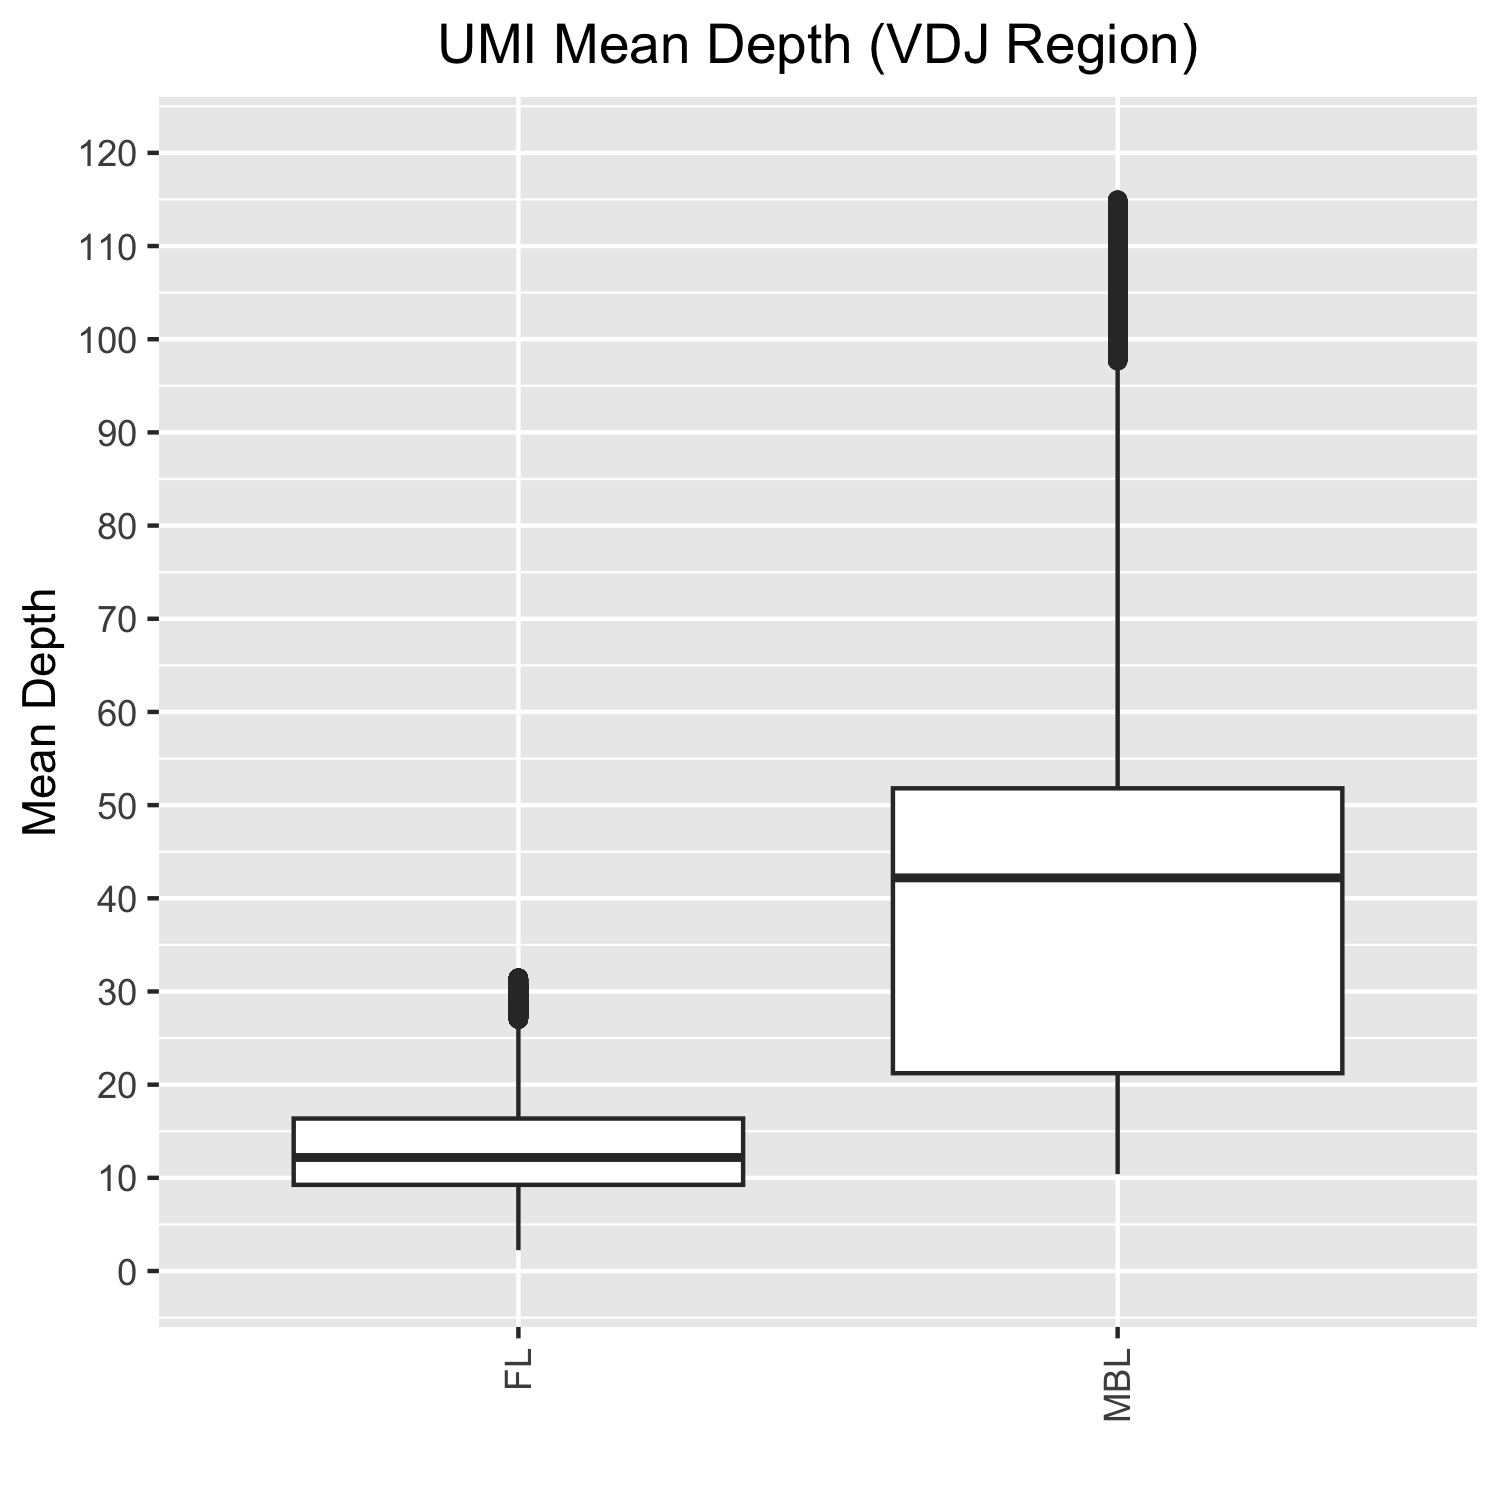

In [22]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 300)

# New facet label names for supp variable
supp.labs <- c("FL", "CLL/MBL")
names(supp.labs) <- c("FL", "MBL")

dd <- ggplot(clean_outliers(df %>% filter(!subject %in% mbl_samples), mean_depth_vdj), aes(x = dataset, y = mean_depth_vdj)) +
  geom_boxplot() +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    plot.title = element_text(hjust = 0.5)
  ) +
#  facet_grid(chain ~ dataset, scales = "free", space = "free_x",labeller = labeller( dataset = supp.labs)) +
  labs(x = "", y = "Mean Depth") +
  ggtitle("UMI Mean Depth (VDJ Region)") +
  scale_y_continuous(limits = c(0, 120), breaks = seq(0, 120, 10))


dd

In [16]:
head(df)

dataset,subject,chain,cell,umi,mean_depth,mean_depth_vdj
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
FL,K1B_S10000,LC,AAACCTGGTCCAGTAT,AACAGTTCGG,21.47007,13.628242
FL,K1B_S10000,LC,AAACCTGGTCCAGTAT,AGTGCAGATT,15.08175,8.481268
FL,K1B_S10000,LC,AAACCTGGTCCAGTAT,ATTTCTTCAT,15.02482,8.913545
FL,K1B_S10000,LC,AAACCTGGTCCAGTAT,CAAGATTCTC,16.97664,12.100865
FL,K1B_S10000,LC,AAACCTGGTCCAGTAT,CACTCGCGCG,16.12555,9.172911
FL,K1B_S10000,LC,AAACCTGGTCCAGTAT,CCGGGCCTGC,13.88759,10.628242


In [23]:
ks.test(df %>% filter(dataset == "FL") %>% pull(mean_depth_vdj),df %>% filter(dataset == "MBL") %>% pull(mean_depth_vdj))

Warning message in ks.test.default(df %>% filter(dataset == "FL") %>% pull(mean_depth_vdj), :
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  df %>% filter(dataset == "FL") %>% pull(mean_depth_vdj) and df %>% filter(dataset == "MBL") %>% pull(mean_depth_vdj)
D = 0.44742, p-value < 2.2e-16
alternative hypothesis: two-sided
